# 🧠 Notebook 8 — Calibration, Evaluation & Explainability
## Independent Cohort Analysis + SHAP Domain Attribution
### CVD Digital Twin Project | CAD_DT_Final

---

## Purpose
This notebook serves as the final analytical layer of the CVD Digital Twin pipeline.
It operates on **two completely independent datasets**:

| Cohort | Size | Source |
|--------|------|--------|
| Lifestyle | ~13,700 samples | Cardio dataset (anthropometric + lifestyle features) |
| Clinical | ~238 samples | Heart disease dataset (clinical measurements) |

**These datasets do not overlap.** No cross-cohort fusion is performed.

### What this notebook does:
1. **Section 2** — Load per-patient integrated risk scores (NB7 outputs)
2. **Section 3** — Meta-calibration per cohort (independent, no cross-cohort stacking)
3. **Section 4** — Platt scaling calibration per cohort
4. **Section 5** — Evaluation: Base vs Integrated vs Calibrated
5. **Section 6** — SHAP explainability on whichever model each cohort's pipeline actually uses (explainer type auto-selected — NB6's 2026-07-25 fix means the clinical model is Logistic Regression, not XGBoost; this notebook no longer assumes either)
6. **Section 7** — Domain attribution (Lifestyle / Clinical / Genetic)
7. **Section 8** — Visualisations (SHAP summary, bar, waterfall, attribution)

---

## What this notebook does **NOT** do
- ❌ Attribute any risk to genetics via SHAP. PRS enters through NB7's post-hoc arithmetic blend (`p_integrated = w1×p_model + w2×sigmoid_prs`), not as a model feature — SHAP can only explain features the model was actually trained on. The "genetic" slice in Section 7's domain attribution is a **fixed constant per patient** (the same `w2×sigmoid_prs` for everyone), not a per-patient SHAP value. This is a scope limitation of the architecture, not a bug, and no amount of rerunning this notebook will ever produce a genetics SHAP value.
- ❌ Assume a fixed model type per cohort. The explainer (Section 6) is chosen based on what `type(clf).__name__` actually is at runtime, printed explicitly, never hardcoded.


> **Edit log — 2026-07-27:**
> - **Blocking bug fixed:** Section 6b called `shap.TreeExplainer(clf_cl)` on the clinical model, which is Logistic Regression as of NB6's 2026-07-25 fix — `TreeExplainer` requires tree-structure attributes a linear model doesn't have, so this crashed Section 6b and everything downstream (Section 7 domain attribution, Section 8 Figures 2–3, Section 9). Replaced with a shared `make_explainer()` helper that dispatches on the classifier's actual type (`TreeExplainer` for tree models, `LinearExplainer` for linear models, generic `shap.Explainer` fallback otherwise) for **both** cohorts, so this can't silently break again if either champion model changes in a future rerun.
> - **Section 3/4 redundancy + leakage fixed:** Section 3 already computed genuinely out-of-fold (`cross_val_predict`) calibrated probabilities and printed their AUC — then Section 4 refit a near-identical Platt-scaling model and evaluated it **in-sample**, and it was Section 4's optimistic in-sample numbers (not Section 3's honest OOF numbers) that fed Section 5's final evaluation table. Fixed: Section 4 still fits and keeps the deployable `CalibratedClassifierCV` object (needed to score future new patients), but the `p_calibrated` column and all reported Brier/AUC metrics now come from Section 3's OOF predictions.
> - **Platt paragraph reframed** (Section 4 markdown): now explicitly states this is correcting the calibration cost NB7's PRS blending step introduces (NB7's own evaluation showed Brier degrading after integration for both cohorts), not a generic textbook calibration-drift caveat.
> - **SHAP-can't-explain-genetics caveat promoted**: was a footnote at the bottom of Section 7's markdown; now stated up top in the header's "what this notebook does NOT do" list and repeated in Section 9's final summary, so it isn't missed by someone skimming.
> - **Domain attribution silent-mismatch risk fixed**: `compute_domain_attribution` now prints any feature names that matched neither domain map before silently dumping their SHAP contribution into 'clinical' — this project has hit real column-naming mismatches before (`chest_pain_type_1.0` vs without `.0`), so this should surface instead of silently skewing the percentages.
> - **`PRS_CONTRIBUTION` no longer hardcoded**: was `0.15 * 0.5023` typed directly into the code (matches the current run by coincidence, not by design — the exact anti-pattern NB3 already caught and fixed once for its SNP count). Now reads the real `sigmoid_prs` value from `prs_population_score.csv` (same file NB7 loads) at runtime; `w2=0.15` stays a documented shared constant matching NB7's decision.
> - Removed "XGBoost" from every title/label that no longer accurately describes the clinical model (Section 0, 6b, 9).


> **Edit log — 2026-07-28 (build-order Steps 1-2):**
> - **Step 1:** Section 4 now saves `ls_calibrator.pkl` and `cl_calibrator.pkl` to `MODEL_DIR` — these were fitted but never persisted before, so nothing downstream could produce a real calibrated probability for a new patient.
> - **Step 2:** Sections 6/6b now each save a small SHAP background sample (`shap_background_lifestyle.pkl` / `shap_background_clinical.pkl`, ≤100 rows) separately from the full SHAP bundle — saving background data rather than the raw explainer object, since the generic-fallback branch of `make_explainer_and_values()` wraps a lambda and lambdas aren't picklable. Background + the already-saved model pickle is sufficient to reconstruct an identical explainer at inference time for NB9a's single-patient scoring.


---
# Section 1 — Setup & Imports

## What & Why
All libraries, paths, and output directories are configured here.  
Centralising configuration eliminates path duplication bugs across sections.  
`exist_ok=True` ensures idempotent directory creation — safe to re-run.

The strict `CAD_DT_Final/` directory tree mirrors NB1–NB7 conventions,
ensuring downstream reproducibility.


In [1]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model   import LogisticRegression
from sklearn.calibration    import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics        import roc_auc_score, brier_score_loss

try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'shap', '-q'], check=True)
    import shap

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('✅ Google Drive mounted')
except ImportError:
    print('ℹ️  Not in Colab — using local paths')

# ── 🔑 SINGLE SOURCE OF TRUTH ────────────────────────────────────────────────
BASE_DIR = "/content/drive/MyDrive/CAD_DT_Final/"

# ── Input paths (NB7 outputs) ─────────────────────────────────────────────────
INTEGRATED_DIR      = os.path.join(BASE_DIR, "Outputs", "Integrated")
LIFESTYLE_SCORES_PATH = os.path.join(INTEGRATED_DIR, "lifestyle_risk_scores_with_prs.csv")
CLINICAL_SCORES_PATH  = os.path.join(INTEGRATED_DIR, "clinical_risk_scores_with_prs.csv")

# ── Raw test data paths (NB1 outputs) ─────────────────────────────────────────
LIFESTYLE_TEST_PATH = os.path.join(BASE_DIR, "Outputs", "Lifestyle", "df_lifestyle_test.csv")
CLINICAL_TEST_PATH  = os.path.join(BASE_DIR, "Outputs", "Clinical",  "df_clinical_test.csv")

# ── Trained pipeline paths (NB5, NB6 outputs) ────────────────────────────────
MODEL_DIR           = os.path.join(BASE_DIR, "Outputs", "Models")
LIFESTYLE_MODEL_PATH = os.path.join(MODEL_DIR, "lifestyle_pipeline.pkl")
CLINICAL_MODEL_PATH  = os.path.join(MODEL_DIR, "clinical_pipeline.pkl")

# ── Output directories ────────────────────────────────────────────────────────
FIG_DIR     = os.path.join(BASE_DIR, "Outputs", "Figures")
EXPL_DIR    = os.path.join(BASE_DIR, "Outputs", "Explainability")

for d in [FIG_DIR, EXPL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── PRS CSV path (added 2026-07-27, for dynamic PRS_CONTRIBUTION in Section 7) ──
GENETICS_DIR = os.path.join(BASE_DIR, "Outputs", "Genetics")
PRS_CSV_PATH = os.path.join(GENETICS_DIR, "prs_population_score.csv")

# ── SHAP output paths ─────────────────────────────────────────────────────────
SHAP_LIFESTYLE_OUT = os.path.join(EXPL_DIR, "shap_values_lifestyle.pkl")
SHAP_CLINICAL_OUT  = os.path.join(EXPL_DIR, "shap_values_clinical.pkl")
DOMAIN_ATTR_OUT    = os.path.join(EXPL_DIR, "domain_attributions.csv")
SHAP_FIG_OUT       = os.path.join(FIG_DIR,  "shap_waterfall_clinical.png")

# ── Constants ─────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TARGET_COL   = 'target'

print('='*60)
print('  NOTEBOOK 8 — Calibration & Explainability')
print('  CVD Digital Twin | CAD_DT_Final')
print('='*60)
print(f'  Lifestyle scores : {LIFESTYLE_SCORES_PATH}')
print(f'  Clinical scores  : {CLINICAL_SCORES_PATH}')
print(f'  Lifestyle model  : {LIFESTYLE_MODEL_PATH}')
print(f'  Clinical model   : {CLINICAL_MODEL_PATH}')
print(f'  Explainability   : {EXPL_DIR}')
print(f'  Figures          : {FIG_DIR}')
print(f'  PRS CSV          : {PRS_CSV_PATH}')

# ── Load real sigmoid_prs (added 2026-07-27) ─────────────────────────────────
# FIX: PRS_CONTRIBUTION in Section 7 used to be hardcoded as 0.15 * 0.5023 — matches
# the current run by coincidence, not by design. Reading the real value here means
# it can never silently go stale if NB4/NB7 numbers change on a future rerun.
assert os.path.isfile(PRS_CSV_PATH), f'❌ PRS CSV not found: {PRS_CSV_PATH}'
_prs_df = pd.read_csv(PRS_CSV_PATH)
assert 'sigmoid_prs' in _prs_df.columns, (
    "❌ 'sigmoid_prs' column not found in PRS CSV — this notebook needs NB4's "
    "2026-07-24 export (prs_z/sigmoid_prs precomputed). Check NB4 version."
)
SIGMOID_PRS = float(_prs_df['sigmoid_prs'].values[0])
W2_GENETIC  = 0.15   # matches NB7's documented fixed weight decision (2026-07-26)
print(f'  sigmoid_prs      : {SIGMOID_PRS:.6f}  (loaded from PRS CSV, not hardcoded)')

# ── Build-order Steps 1-2 (added 2026-07-28): deployable calibrators + SHAP background ──
LS_CALIBRATOR_OUT   = os.path.join(MODEL_DIR, 'ls_calibrator.pkl')
CL_CALIBRATOR_OUT   = os.path.join(MODEL_DIR, 'cl_calibrator.pkl')
SHAP_LS_BG_OUT      = os.path.join(EXPL_DIR, 'shap_background_lifestyle.pkl')
SHAP_CL_BG_OUT      = os.path.join(EXPL_DIR, 'shap_background_clinical.pkl')
print(f'  LS calibrator out: {LS_CALIBRATOR_OUT}')
print(f'  CL calibrator out: {CL_CALIBRATOR_OUT}')

print('\n[SECTION 1 COMPLETE] ✅')


Mounted at /content/drive
✅ Google Drive mounted
  NOTEBOOK 8 — Calibration & Explainability
  CVD Digital Twin | CAD_DT_Final
  Lifestyle scores : /content/drive/MyDrive/CAD_DT_Final/Outputs/Integrated/lifestyle_risk_scores_with_prs.csv
  Clinical scores  : /content/drive/MyDrive/CAD_DT_Final/Outputs/Integrated/clinical_risk_scores_with_prs.csv
  Lifestyle model  : /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/lifestyle_pipeline.pkl
  Clinical model   : /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/clinical_pipeline.pkl
  Explainability   : /content/drive/MyDrive/CAD_DT_Final/Outputs/Explainability
  Figures          : /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures
  PRS CSV          : /content/drive/MyDrive/CAD_DT_Final/Outputs/Genetics/prs_population_score.csv
  sigmoid_prs      : 0.502258  (loaded from PRS CSV, not hardcoded)
  LS calibrator out: /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/ls_calibrator.pkl
  CL calibrator out: /content/drive/MyDrive/CAD_DT_Fi

---
# Section 2 — Load Integrated Risk Scores

## What is being done
NB7 produced genetically-adjusted per-patient risk scores for each cohort independently.
These CSVs are loaded here. Each file contains three columns:

| Column | Description |
|--------|-------------|
| `y_true` | Ground-truth binary label (0 = no CAD, 1 = CAD) |
| `p_base` | Predicted probability from the base ML model |
| `p_integrated` | PRS-adjusted integrated probability (NB7 formula) |

## Why it is needed
Downstream calibration and evaluation require both the raw model scores (`p_base`)
and the PRS-corrected scores (`p_integrated`) so we can measure the added value of
genetic adjustment.

## What insight it provides
Comparing dataset sizes confirms the two cohorts remain independent pipelines.
Null checks prevent silent downstream errors caused by missing imputation.


In [2]:
print('='*60)
print('  SECTION 2: Load Integrated Risk Scores')
print('='*60)

# ── Load scores ───────────────────────────────────────────────────────────────
ls_scores = pd.read_csv(LIFESTYLE_SCORES_PATH)
cl_scores = pd.read_csv(CLINICAL_SCORES_PATH)

print(f'\n  Lifestyle scores shape : {ls_scores.shape}')
print(f'  Clinical  scores shape : {cl_scores.shape}')

# ── Validate required columns ─────────────────────────────────────────────────
REQUIRED_COLS = ['y_true', 'p_base', 'p_integrated']

for label, df in [('Lifestyle', ls_scores), ('Clinical', cl_scores)]:
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    assert not missing, f"❌ {label} scores missing columns: {missing}"
    assert df[REQUIRED_COLS].isnull().sum().sum() == 0, f"❌ Nulls found in {label} scores"
    print(f'  ✅ {label}: columns OK, no nulls — {len(df):,} rows')

# ── Summarise class balance ────────────────────────────────────────────────────
for label, df in [('Lifestyle', ls_scores), ('Clinical', cl_scores)]:
    vc = df['y_true'].value_counts(normalize=True)
    print(f'  {label} class balance → 0: {vc.get(0,0)*100:.1f}%  |  1: {vc.get(1,0)*100:.1f}%')

print('\n[SECTION 2 COMPLETE] ✅')


  SECTION 2: Load Integrated Risk Scores

  Lifestyle scores shape : (13720, 6)
  Clinical  scores shape : (184, 6)
  ✅ Lifestyle: columns OK, no nulls — 13,720 rows
  ✅ Clinical: columns OK, no nulls — 184 rows
  Lifestyle class balance → 0: 50.5%  |  1: 49.5%
  Clinical class balance → 0: 44.6%  |  1: 55.4%

[SECTION 2 COMPLETE] ✅


---
# Section 3 — Meta-Calibration (Per-Cohort, Not Cross-Cohort)

## What is being done
A simple logistic regression meta-model is trained on each cohort's `p_integrated`
scores **separately** using out-of-fold (OOF) cross-validation predictions.

The input feature matrix is deliberately one-dimensional:

```
X_meta = p_integrated.reshape(-1, 1)   # shape: (n_samples, 1)
```

## Why it is needed
`cross_val_predict(..., method='predict_proba')` generates OOF predictions without
data leakage — each prediction is made on a fold the meta-model never saw during
fitting (Wolpert, 1992). This avoids overly optimistic calibration estimates.

**Crucially**, this is performed independently for each cohort.
Cross-cohort stacking would require aligned patient indices across the two datasets,
which is impossible given they originate from different studies.

## What insight it provides
OOF meta-predictions show how much the integrated score can be further refined by
a re-calibration pass. A well-calibrated model's OOF AUC should closely track
the direct `p_integrated` AUC — large discrepancies indicate calibration drift.

**Fixed 2026-07-27:** this OOF output (`p_meta_oof`) is now the actual reported "calibrated" score in Section 5/9 — previously Section 4's in-sample refit (a leakier, more optimistic number) was used instead, even though this section had already done the honest version and its output went unused. See Section 4 for how the two are now reconciled.


In [3]:
print('='*60)
print('  SECTION 3: Meta-Calibration (OOF, Per-Cohort)')
print('='*60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def oof_meta_calibrate(scores_df, label):
    """
    Fit a 1-D logistic meta-model on p_integrated via OOF cross-validation.
    Returns OOF meta-probabilities and AUC.
    """
    X_meta = scores_df[['p_integrated']].values          # shape (n, 1)
    y      = scores_df['y_true'].values

    meta_lr = LogisticRegression(C=1.0, max_iter=500, solver='lbfgs')

    oof_proba = cross_val_predict(
        meta_lr, X_meta, y,
        cv=skf,
        method='predict_proba'
    )[:, 1]                                              # class-1 probability

    auc = roc_auc_score(y, oof_proba)
    print(f'  {label} — OOF Meta AUC: {auc:.4f}  (n={len(y):,})')
    return oof_proba, auc

ls_oof_proba, ls_oof_auc = oof_meta_calibrate(ls_scores, 'Lifestyle')
cl_oof_proba, cl_oof_auc = oof_meta_calibrate(cl_scores, 'Clinical')

# Attach OOF predictions for downstream evaluation
ls_scores = ls_scores.copy()
cl_scores = cl_scores.copy()
ls_scores['p_meta_oof'] = ls_oof_proba
cl_scores['p_meta_oof'] = cl_oof_proba

print('\n[SECTION 3 COMPLETE] ✅')


  SECTION 3: Meta-Calibration (OOF, Per-Cohort)
  Lifestyle — OOF Meta AUC: 0.8022  (n=13,720)
  Clinical — OOF Meta AUC: 0.8896  (n=184)

[SECTION 3 COMPLETE] ✅


---
# Section 4 — Platt Scaling Calibration (Per-Cohort)

## What is being done
A `CalibratedClassifierCV` with `method='sigmoid'` (Platt scaling) and `cv=5` is fitted on each cohort's `p_integrated` scores, producing a deployable calibrator for scoring future new patients. **The Brier/AUC numbers reported for this step are Section 3's out-of-fold predictions, not this calibrator's in-sample output** (fixed 2026-07-27 — see edit log).

## Why it is needed — reframed 2026-07-27
This is **not** a generic "even good models sometimes drift" calibration step. NB7's own evaluation showed Brier score getting measurably *worse* after PRS integration for both cohorts — because `p_integrated = w1×p_model + w2×sigmoid_prs` is a fixed arithmetic blend, not a probability-preserving operation. Blending in a population-constant offset predictably shifts calibration even though it can't change AUC (see NB7 Section 6 for the measured ΔAUC≈0, ΔBrier>0 pattern). Platt scaling here specifically corrects **the calibration cost that PRS integration itself introduced** — it's cleanup after a known, deliberate side effect of NB7's blending step, not an independent quality check applied out of general caution.

Sigmoid calibration is preferred here over isotonic regression because:
- The dataset sizes are modest (especially clinical ~184–238 rows)
- Isotonic regression risks overfitting on small samples
- Platt scaling is analytically interpretable

## What insight it provides
Comparing pre- and post-calibration Brier scores quantifies how much of the PRS-integration calibration cost gets recovered. A well-calibrated model should show lower Brier score after Platt scaling than `p_integrated` had.


In [4]:
print('=' * 60)
print('  SECTION 4: Platt Scaling Calibration (Per-Cohort)')
print('=' * 60)

def fit_platt_calibration(scores_df, oof_proba, label):
    """
    Fits CalibratedClassifierCV(LogisticRegression, sigmoid, cv=5) on p_integrated —
    this fitted object is what you'd save/reuse to score a brand-new patient later.

    FIX (2026-07-27): the *reported* Brier/AUC below use `oof_proba` (Section 3's
    genuine out-of-fold predictions), not this calibrator's own in-sample
    `.predict_proba()` on its own training data — the previous version reported the
    latter, which is mildly optimistic (some rows are scored by a fold-model that
    saw them during its own training). Section 3's OOF numbers are the honest ones.
    """
    X_cal = scores_df[['p_integrated']].values
    y     = scores_df['y_true'].values

    base_lr    = LogisticRegression(C=1.0, max_iter=500, solver='lbfgs')
    calibrated = CalibratedClassifierCV(base_lr, method='sigmoid', cv=5)
    calibrated.fit(X_cal, y)   # deployable object; NOT used for the reported metrics below

    brier_before = brier_score_loss(y, scores_df['p_integrated'].values)
    brier_after  = brier_score_loss(y, oof_proba)   # FIX: OOF, not calibrated.predict_proba(X_cal)

    print(f'  {label}:')
    print(f'    Brier (p_integrated)      : {brier_before:.4f}')
    print(f'    Brier (calibrated, OOF)   : {brier_after:.4f}')
    delta = brier_before - brier_after
    print(f'    Δ Brier (improvement)     : {delta:+.4f}')
    return calibrated, oof_proba   # oof_proba becomes this cohort's p_calibrated

ls_calibrator, ls_p_cal = fit_platt_calibration(ls_scores, ls_oof_proba, 'Lifestyle')
cl_calibrator, cl_p_cal = fit_platt_calibration(cl_scores, cl_oof_proba, 'Clinical')

ls_scores['p_calibrated'] = ls_p_cal
cl_scores['p_calibrated'] = cl_p_cal

# ── Build-order STEP 1 (added 2026-07-28) ────────────────────────────────────
# Without this, nothing downstream (NB9a single-patient scoring) can produce a
# real calibrated probability for a new patient — ls_calibrator/cl_calibrator
# were fitted above but never persisted, so they only ever existed in-memory
# for the duration of this run.
with open(LS_CALIBRATOR_OUT, 'wb') as f:
    pickle.dump(ls_calibrator, f)
with open(CL_CALIBRATOR_OUT, 'wb') as f:
    pickle.dump(cl_calibrator, f)
print(f'  ✅ Calibrator saved: {LS_CALIBRATOR_OUT}')
print(f'  ✅ Calibrator saved: {CL_CALIBRATOR_OUT}')

print('\n[SECTION 4 COMPLETE] ✅')


  SECTION 4: Platt Scaling Calibration (Per-Cohort)
  Lifestyle:
    Brier (p_integrated)      : 0.1814
    Brier (calibrated, OOF)   : 0.1800
    Δ Brier (improvement)     : +0.0013
  Clinical:
    Brier (p_integrated)      : 0.1394
    Brier (calibrated, OOF)   : 0.1455
    Δ Brier (improvement)     : -0.0061
  ✅ Calibrator saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/ls_calibrator.pkl
  ✅ Calibrator saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/cl_calibrator.pkl

[SECTION 4 COMPLETE] ✅


---
# Section 5 — Evaluation: Base vs Integrated vs Calibrated

## What is being done
All three probability estimates are evaluated on their respective held-out cohorts
using two complementary metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| `Test_AUC` | Area under ROC curve | Discriminative ability (threshold-free) |
| `Test_Brier` | Mean squared error of probabilities | Calibration + discrimination combined |

## Why it is needed
A model can have high AUC but poor calibration (overconfident or underconfident
probability estimates). Reporting both metrics together reveals whether PRS integration
and Platt scaling improve both discrimination and calibration simultaneously.

## What insight it provides
- If `p_integrated` AUC > `p_base` AUC → genetic adjustment improves discrimination
- If calibrated Brier < integrated Brier → Platt scaling improves probability quality
- Results are reported per-cohort — no cross-cohort averaging


In [5]:
print('='*60)
print('  SECTION 5: Evaluation — Base vs Integrated vs Calibrated')
print('='*60)

eval_rows = []

for label, df in [('Lifestyle', ls_scores), ('Clinical', cl_scores)]:
    y = df['y_true'].values
    for model_name, col in [
        (f'{label} — Base',        'p_base'),
        (f'{label} — Integrated',  'p_integrated'),
        (f'{label} — Calibrated',  'p_calibrated'),
    ]:
        proba = df[col].values
        auc   = roc_auc_score(y, proba)
        brier = brier_score_loss(y, proba)
        eval_rows.append({
            'Cohort'   : label,
            'Model'    : model_name,
            'Test_AUC' : round(auc,   4),
            'Test_Brier': round(brier, 4),
        })

eval_df = pd.DataFrame(eval_rows)
print('\n' + eval_df.to_string(index=False))

# ── Save evaluation table ─────────────────────────────────────────────────────
EVAL_OUT = os.path.join(BASE_DIR, 'Outputs', 'Integrated', 'nb8_evaluation_summary.csv')
eval_df.to_csv(EVAL_OUT, index=False)
print(f'\n  ✅ Evaluation table saved: {EVAL_OUT}')
print('\n[SECTION 5 COMPLETE] ✅')


  SECTION 5: Evaluation — Base vs Integrated vs Calibrated

   Cohort                  Model  Test_AUC  Test_Brier
Lifestyle       Lifestyle — Base    0.8024      0.1796
Lifestyle Lifestyle — Integrated    0.8024      0.1814
Lifestyle Lifestyle — Calibrated    0.8022      0.1800
 Clinical        Clinical — Base    0.8935      0.1338
 Clinical  Clinical — Integrated    0.8935      0.1394
 Clinical  Clinical — Calibrated    0.8896      0.1455

  ✅ Evaluation table saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Integrated/nb8_evaluation_summary.csv

[SECTION 5 COMPLETE] ✅


---
# Section 6 — SHAP Explainability: Lifestyle Model

## What is being done
SHAP (SHapley Additive exPlanations; Lundberg & Lee, NeurIPS 2017) values are computed for whichever model NB5 actually selected as the lifestyle champion.

**Fixed 2026-07-27:** the explainer is no longer hardcoded to `TreeExplainer` (which assumed XGBoost). A shared `make_explainer()` helper below picks `shap.TreeExplainer` for tree-based models, `shap.LinearExplainer` for linear models, or a generic `shap.Explainer` fallback — based on `type(clf).__name__`, checked and printed at runtime, never assumed. This matters concretely: NB6's 2026-07-25 fix changed the clinical champion from XGBoost to Logistic Regression, and the old hardcoded `TreeExplainer` call would crash outright on that model.

Extracting the inner classifier:
```python
inner_pipe = pipeline.calibrated_classifiers_[0].estimator
scaler     = inner_pipe.named_steps['scaler']
clf        = inner_pipe.named_steps['clf']
```
**Caveat (documented 2026-07-27, not previously stated):** this uses only the *first* of the 5 cross-validated sub-models inside `CalibratedClassifierCV` — the deployed prediction actually averages all 5. These SHAP values explain one representative fold's classifier, not the exact averaged ensemble producing the reported AUC/Brier numbers. A reasonable practical simplification, but not identical to the deployed model.

Raw features are **scaled before SHAP** using the same fitted scaler, ensuring the explainer operates in the same feature space the model was trained on.

## Why it is needed
Tree SHAP (`shap.TreeExplainer`) provides exact Shapley values in polynomial time for tree-based models. For linear models, `shap.LinearExplainer` is the exact, efficient equivalent — computing the same Shapley-consistent attributions without needing a tree structure that doesn't exist for a linear model. Both satisfy **efficiency**, **symmetry**, **dummy**, and **additivity** axioms — properties violated by simpler importance methods (e.g., Gini impurity decrease, permutation importance).

## What insight it provides
Per-patient SHAP values reveal *which features* and *in which direction* each feature pushed the predicted CAD probability, enabling clinical interpretation of model decisions beyond aggregate feature importance.

**Lifestyle cohort**: capped at 2,000 randomly sampled rows for computational efficiency (SHAP scales quadratically with sample size for dense explanations).


In [6]:
print('=' * 60)
print('  SECTION 6: SHAP — Lifestyle Model')
print('=' * 60)

# ── Shared explainer dispatcher (added 2026-07-27) ──────────────────────────────
# FIX: replaces two duplicated, hardcoded shap.TreeExplainer(...) calls (Section 6
# and 6b) that assumed both champion models are tree-based. NB6's 2026-07-25 fix
# made the clinical champion Logistic Regression, which crashes TreeExplainer
# outright. This dispatches on the classifier's real type instead of assuming.
TREE_MODEL_TYPES = {
    'XGBClassifier', 'RandomForestClassifier', 'GradientBoostingClassifier',
    'LGBMClassifier', 'ExtraTreesClassifier', 'DecisionTreeClassifier',
}

def make_explainer_and_values(clf, X_background):
    """
    Returns (shap_values, expected_value, explainer_type_used) for whatever
    classifier is actually passed in — never assumes tree vs linear.
    """
    model_type = type(clf).__name__

    if model_type in TREE_MODEL_TYPES:
        explainer = shap.TreeExplainer(clf)
        shap_vals = explainer.shap_values(X_background)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]   # class-1 (CAD positive)
        ev = explainer.expected_value
        expected_value = float(ev[1]) if isinstance(ev, (list, np.ndarray)) else float(ev)
        explainer_used = 'TreeExplainer'

    elif hasattr(clf, 'coef_'):
        explainer = shap.LinearExplainer(clf, X_background)
        shap_vals = explainer.shap_values(X_background)
        ev = explainer.expected_value
        expected_value = float(ev[0]) if isinstance(ev, (list, np.ndarray)) else float(ev)
        explainer_used = 'LinearExplainer'

    else:
        f = lambda X: clf.predict_proba(X)[:, 1]
        explainer = shap.Explainer(f, X_background)
        exp = explainer(X_background)
        shap_vals = exp.values
        expected_value = float(np.mean(exp.base_values))
        explainer_used = 'shap.Explainer (generic, predict_proba class-1)'

    return shap_vals, expected_value, explainer_used

# ── Load lifestyle pipeline ───────────────────────────────────────────────────
with open(LIFESTYLE_MODEL_PATH, 'rb') as f:
    lifestyle_pipeline = pickle.load(f)

print(f'  Loaded: {type(lifestyle_pipeline).__name__}')

# ── Extract scaler + classifier from pipeline ─────────────────────────────────
inner_pipe_ls = lifestyle_pipeline.calibrated_classifiers_[0].estimator
scaler_ls     = inner_pipe_ls.named_steps['scaler']
clf_ls        = inner_pipe_ls.named_steps['clf']

print(f'  Scaler type : {type(scaler_ls).__name__}')
print(f'  Classifier  : {type(clf_ls).__name__}')

# ── Load raw test data ────────────────────────────────────────────────────────
df_ls_test = pd.read_csv(LIFESTYLE_TEST_PATH)

if hasattr(scaler_ls, 'feature_names_in_'):
    LS_FEATURES = scaler_ls.feature_names_in_.tolist()
else:
    LS_FEATURES = df_ls_test.drop(columns=[TARGET_COL], errors='ignore').columns.tolist()

X_ls_test = df_ls_test[LS_FEATURES]

# ── Subsample to ≤ 2000 rows ──────────────────────────────────────────────────
SHAP_MAX_LS = 2000
if len(X_ls_test) > SHAP_MAX_LS:
    np.random.seed(RANDOM_STATE)
    idx_shap = np.random.choice(len(X_ls_test), SHAP_MAX_LS, replace=False)
    X_shap_ls = X_ls_test.iloc[idx_shap].reset_index(drop=True)
else:
    X_shap_ls = X_ls_test.reset_index(drop=True)

print(f'\n  SHAP sample size : {len(X_shap_ls):,} rows')
print(f'  Features ({len(LS_FEATURES)}): {LS_FEATURES}')

# ── Scale features ────────────────────────────────────────────────────────────
X_shap_ls_scaled = pd.DataFrame(
    scaler_ls.transform(X_shap_ls),
    columns=LS_FEATURES
)

# ── Compute SHAP values (auto-dispatched, added 2026-07-27) ───────────────────
print('\n  Computing SHAP values ...')
shap_values_ls, expected_value_ls, explainer_used_ls = make_explainer_and_values(
    clf_ls, X_shap_ls_scaled
)
print(f'  Explainer used   : {explainer_used_ls}')
print(f'  SHAP values shape: {shap_values_ls.shape}')

# ── Save SHAP bundle ──────────────────────────────────────────────────────────
shap_ls_data = {
    'shap_values'   : shap_values_ls,
    'feature_names' : LS_FEATURES,
    'X_scaled'      : X_shap_ls_scaled,
    'X_raw'         : X_shap_ls,
    'expected_value': expected_value_ls,
    'explainer_used': explainer_used_ls,
}
with open(SHAP_LIFESTYLE_OUT, 'wb') as f:
    pickle.dump(shap_ls_data, f)
print(f'  ✅ SHAP bundle saved: {SHAP_LIFESTYLE_OUT}')

# ── Global importance summary ─────────────────────────────────────────────────
mean_abs_shap_ls = np.abs(shap_values_ls).mean(axis=0)
shap_imp_ls = pd.DataFrame({
    'Feature'    : LS_FEATURES,
    'MeanAbsSHAP': mean_abs_shap_ls
}).sort_values('MeanAbsSHAP', ascending=False)

print(f'\n  Top features by mean |SHAP| (Lifestyle):')
print(shap_imp_ls.head(10).to_string(index=False))

# ── Build-order STEP 2 (added 2026-07-28) ────────────────────────────────────
# Saves a small background sample separately (not just embedded in shap_ls_data)
# so a future single-patient scoring module can rebuild an explainer via
# make_explainer_and_values(clf, background) without loading the full SHAP
# bundle (which also holds the full 2000-row shap_values array).
# NOTE: saving background data, not the raw explainer object — the generic
# fallback branch of make_explainer_and_values() wraps a lambda, which is not
# picklable, so this is the robust choice regardless of which branch fires.
_bg_sample_ls = X_shap_ls_scaled.sample(min(100, len(X_shap_ls_scaled)), random_state=RANDOM_STATE)
with open(SHAP_LS_BG_OUT, 'wb') as f:
    pickle.dump({'background': _bg_sample_ls, 'feature_names': LS_FEATURES,
                 'clf_type': type(clf_ls).__name__}, f)
print(f'  ✅ SHAP background saved: {SHAP_LS_BG_OUT} ({len(_bg_sample_ls)} rows)')

print('\n[SECTION 6 COMPLETE] ✅')


  SECTION 6: SHAP — Lifestyle Model
  Loaded: CalibratedClassifierCV
  Scaler type : StandardScaler
  Classifier  : XGBClassifier

  SHAP sample size : 2,000 rows
  Features (14): ['age', 'gender', 'systolic_bp', 'diastolic_bp', 'smoking', 'alcohol', 'physical_activity', 'bmi', 'cholesterol_level_1', 'cholesterol_level_2', 'cholesterol_level_3', 'glucose_level_1', 'glucose_level_2', 'glucose_level_3']

  Computing SHAP values ...
  Explainer used   : TreeExplainer
  SHAP values shape: (2000, 14)
  ✅ SHAP bundle saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Explainability/shap_values_lifestyle.pkl

  Top features by mean |SHAP| (Lifestyle):
            Feature  MeanAbsSHAP
        systolic_bp     0.818281
                age     0.298841
cholesterol_level_3     0.134060
       diastolic_bp     0.131120
                bmi     0.131084
cholesterol_level_1     0.111619
  physical_activity     0.069161
            smoking     0.028602
    glucose_level_3     0.028133
             gend

---
# Section 6b — SHAP Explainability: Clinical Model

## What is being done
Identical SHAP extraction procedure applied to the clinical pipeline (NB6), using the same `make_explainer_and_values()` helper from Section 6 — **not** a hardcoded `TreeExplainer` call. This matters concretely here: the clinical champion model is Logistic Regression as of NB6's 2026-07-25 gap-aware selection fix, not XGBoost, so `shap.LinearExplainer` is what actually runs for this cohort (printed explicitly below, not assumed).

The clinical dataset is small (~184 test rows), so **all rows** are used for SHAP without subsampling — no information is discarded.

## Why it is needed
Clinical features (resting BP, cholesterol, max heart rate, ECG results, oldpeak) have different mechanistic relationships to CAD compared to lifestyle features. Separate SHAP analysis preserves these domain-specific patterns and prevents lifestyle features from dominating the explanation space.

## What insight it provides
Feature attributions for clinical markers directly map to established cardiovascular risk factors (Framingham Risk Score components), enabling cardiologists to validate model reasoning against clinical domain knowledge.


In [7]:
print('=' * 60)
print('  SECTION 6b: SHAP — Clinical Model')
print('=' * 60)

# ── Load clinical pipeline ────────────────────────────────────────────────────
with open(CLINICAL_MODEL_PATH, 'rb') as f:
    clinical_pipeline = pickle.load(f)

print(f'  Loaded: {type(clinical_pipeline).__name__}')

# ── Extract scaler + classifier ───────────────────────────────────────────────
inner_pipe_cl = clinical_pipeline.calibrated_classifiers_[0].estimator
scaler_cl     = inner_pipe_cl.named_steps['scaler']
clf_cl        = inner_pipe_cl.named_steps['clf']

print(f'  Scaler type : {type(scaler_cl).__name__}')
print(f'  Classifier  : {type(clf_cl).__name__}')

# ── Load raw test data ────────────────────────────────────────────────────────
df_cl_test = pd.read_csv(CLINICAL_TEST_PATH)

# Derive feature names directly from the fitted scaler — this is the robust
# selection method (matches NB7's pattern); no need to separately hardcode a
# drop-columns list, since whatever the scaler was actually fit on IS the answer.
if hasattr(scaler_cl, 'feature_names_in_'):
    CL_FEATURES = scaler_cl.feature_names_in_.tolist()
else:
    CL_FEATURES = df_cl_test.drop(columns=[TARGET_COL], errors='ignore').columns.tolist()

X_cl_test = df_cl_test[CL_FEATURES]

print(f'\n  SHAP sample size : {len(X_cl_test)} rows (full clinical test set)')
print(f'  Features ({len(CL_FEATURES)}): {CL_FEATURES}')

# ── Scale features ────────────────────────────────────────────────────────────
X_shap_cl_scaled = pd.DataFrame(
    scaler_cl.transform(X_cl_test),
    columns=CL_FEATURES
)

# ── Compute SHAP values (auto-dispatched, added 2026-07-27) ───────────────────
print('\n  Computing SHAP values ...')
shap_values_cl, expected_value_cl, explainer_used_cl = make_explainer_and_values(
    clf_cl, X_shap_cl_scaled
)
print(f'  Explainer used   : {explainer_used_cl}')
print(f'  SHAP values shape: {shap_values_cl.shape}')

# ── Save SHAP bundle ──────────────────────────────────────────────────────────
shap_cl_data = {
    'shap_values'   : shap_values_cl,
    'feature_names' : CL_FEATURES,
    'X_scaled'      : X_shap_cl_scaled,
    'X_raw'         : X_cl_test.reset_index(drop=True),
    'expected_value': expected_value_cl,
    'explainer_used': explainer_used_cl,
}
with open(SHAP_CLINICAL_OUT, 'wb') as f:
    pickle.dump(shap_cl_data, f)
print(f'  ✅ SHAP bundle saved: {SHAP_CLINICAL_OUT}')

# ── Global importance summary ─────────────────────────────────────────────────
mean_abs_shap_cl = np.abs(shap_values_cl).mean(axis=0)
shap_imp_cl = pd.DataFrame({
    'Feature'    : CL_FEATURES,
    'MeanAbsSHAP': mean_abs_shap_cl
}).sort_values('MeanAbsSHAP', ascending=False)

print(f'\n  Top features by mean |SHAP| (Clinical):')
print(shap_imp_cl.head(10).to_string(index=False))

# ── Build-order STEP 2 (added 2026-07-28) ────────────────────────────────────
# Same rationale as Section 6 — separate, small background file for fast reuse
# by a future single-patient scoring module.
_bg_sample_cl = X_shap_cl_scaled.sample(min(100, len(X_shap_cl_scaled)), random_state=RANDOM_STATE)
with open(SHAP_CL_BG_OUT, 'wb') as f:
    pickle.dump({'background': _bg_sample_cl, 'feature_names': CL_FEATURES,
                 'clf_type': type(clf_cl).__name__}, f)
print(f'  ✅ SHAP background saved: {SHAP_CL_BG_OUT} ({len(_bg_sample_cl)} rows)')

print('\n[SECTION 6b COMPLETE] ✅')


  SECTION 6b: SHAP — Clinical Model
  Loaded: CalibratedClassifierCV
  Scaler type : StandardScaler
  Classifier  : LogisticRegression



  SHAP sample size : 184 rows (full clinical test set)
  Features (10): ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'oldpeak', 'resting_ecg_0.0', 'resting_ecg_1.0', 'resting_ecg_2.0']

  Computing SHAP values ...
  Explainer used   : LinearExplainer
  SHAP values shape: (184, 10)
  ✅ SHAP bundle saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Explainability/shap_values_clinical.pkl

  Top features by mean |SHAP| (Clinical):
            Feature  MeanAbsSHAP
            oldpeak     0.597025
     max_heart_rate     0.559797
fasting_blood_sugar     0.410458
                sex     0.382800
        cholesterol     0.128182
                age     0.068150
    resting_ecg_2.0     0.065947
    resting_ecg_0.0     0.055778
         resting_bp     0.030115
    resting_ecg_1.0     0.004807
  ✅ SHAP background saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Explainability/shap_background_clinical.pkl (100 rows)

[SECTION 6b COMPLETE] ✅


---
# Section 7 — Domain Attribution

## What is being done
Individual SHAP values are aggregated into three **clinical knowledge domains**:

| Domain | Features included |
|--------|------------------|
| **Lifestyle** | Smoking, alcohol, physical activity, BMI, age, sex |
| **Clinical** | Resting BP, cholesterol, max heart rate, ECG indices, oldpeak |
| **Genetic** | PRS contribution = w₂ × prs_sigmoid (fixed constant from NB7) |

For each patient *i* and domain *d*:

```
attribution_d(i) = Σ |SHAP_f(i)| for f ∈ domain_d
```

These raw sums are normalised to percentages per patient:

```
%_d(i) = attribution_d(i) / Σ_d' attribution_d'(i) × 100
```

## Why it is needed
Raw SHAP values answer *"which feature matters most?"* but clinicians need answers
at the domain level: *"is this patient's risk dominated by lifestyle, clinical
measurements, or inherited genetic predisposition?"*

Domain attribution bridges statistical ML output and clinical decision-making,
enabling personalised prevention strategies.

## What insight it provides
- Patients with high lifestyle domain attribution benefit most from behavioural interventions
- Patients with high genetic attribution require primary prevention screening
- Patients with high clinical attribution may benefit from pharmacological treatment
- Attribution patterns can be compared across the lifestyle vs clinical cohorts

The genetic contribution is modelled as a **fixed constant** (`w2 × sigmoid_prs`, loaded from NB4's real output — see header) because PRS is not a per-sample SHAP-tractable feature in these pipelines — it enters via NB7's post-hoc integration formula, not as a feature either model was trained on. Restated from the header: **this is a scope limitation of the architecture, not something a different SHAP setting or rerun could fix.**


In [8]:
print('='*60)
print('  SECTION 7: Domain Attribution')
print('='*60)

# ── Domain feature mappings ───────────────────────────────────────────────────
# NOTE: feature names must exactly match those in the fitted scaler.
# Unknown features are silently assigned zero attribution via dict.get(f, 0.0).

LS_DOMAIN_MAP = {
    'lifestyle': [
        'smoke', 'alco', 'active', 'bmi',
        # Alternative naming variants from some preprocessing versions:
        'smoking', 'alcohol', 'physical_activity',
    ],
    'clinical': [
        'age', 'gender', 'height', 'weight',
        'systolic_bp', 'diastolic_bp',
        'cholesterol_level_1', 'cholesterol_level_2', 'cholesterol_level_3',
        'glucose_level_1', 'glucose_level_2', 'glucose_level_3',
        # Alternative naming variants:
        'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
    ],
}

CL_DOMAIN_MAP = {
    'clinical': [
        'age', 'resting_bp', 'cholesterol', 'max_heart_rate', 'oldpeak',
        'fasting_blood_sugar',
        'resting_ecg_0.0', 'resting_ecg_1.0', 'resting_ecg_2.0',
        # Numerical/alternative variants:
        'sex', 'trestbps', 'chol', 'thalach', 'ca', 'thal',
    ],
    'lifestyle': [
        # In the clinical dataset lifestyle proxies are limited
        # age and sex serve as demographic risk factors
    ],
}

# PRS genetic contribution (added 2026-07-27: reads real values, not hardcoded)
# w2 and sigmoid_prs both come from Section 1's loaded PRS CSV / NB7's documented
# weight, not a typed-in literal that could silently go stale on a future rerun.
PRS_CONTRIBUTION = W2_GENETIC * SIGMOID_PRS
print(f'  PRS_CONTRIBUTION = {W2_GENETIC} * {SIGMOID_PRS:.6f} = {PRS_CONTRIBUTION:.6f}')

def compute_domain_attribution(shap_vals, feature_names, domain_map, prs_contribution, cohort_label):
    """
    For each patient, compute sum(|SHAP|) per domain, add fixed genetic contribution,
    and normalise to percentages.

    Parameters
    ----------
    shap_vals       : np.ndarray, shape (n_patients, n_features)
    feature_names   : list of str
    domain_map      : dict {domain_name: [feature_names]}
    prs_contribution: float, fixed genetic offset per patient
    cohort_label    : str

    Returns
    -------
    pd.DataFrame with columns: patient_idx, source, lifestyle, clinical, genetic
    """
    rows = []
    assigned_feats = {f for feats in domain_map.values() for f in feats}
    unmatched_features_seen = set()   # FIX (2026-07-27): track, don't silently absorb

    for i in range(len(shap_vals)):
        row_shap = dict(zip(feature_names, np.abs(shap_vals[i])))

        domain_sums = {}
        for domain, feats in domain_map.items():
            domain_sums[domain] = sum(row_shap.get(f, 0.0) for f in feats)

        # Genetic = fixed PRS offset (not a model feature, enters via NB7 formula)
        domain_sums['genetic'] = prs_contribution

        # FIX (2026-07-27): features matching neither domain map used to be silently
        # dumped into 'clinical' with no warning. This project has hit real column-
        # naming mismatches before (chest_pain_type_1.0 vs without .0) — now any such
        # feature is tracked and reported after the loop instead of silently absorbed.
        this_row_unmatched = {k for k in row_shap if k not in assigned_feats}
        unmatched_features_seen.update(this_row_unmatched)
        unassigned = sum(v for k, v in row_shap.items() if k not in assigned_feats)
        domain_sums['clinical'] = domain_sums.get('clinical', 0.0) + unassigned

        total = sum(domain_sums.values())
        if total > 1e-9:
            norm = {k: v / total * 100 for k, v in domain_sums.items()}
        else:
            norm = {k: 0.0 for k in domain_sums}

        norm['patient_idx'] = i
        norm['source']      = cohort_label
        rows.append(norm)

    if unmatched_features_seen:
        print(f'  ⚠️  {cohort_label}: {len(unmatched_features_seen)} feature(s) matched '
              f'NEITHER domain map and were folded into "clinical" by default: '
              f'{sorted(unmatched_features_seen)}')
        print(f'      Check LS_DOMAIN_MAP/CL_DOMAIN_MAP above — this can silently skew '
              f'the reported percentages if it is not intentional.')
    else:
        print(f'  ✅ {cohort_label}: every feature matched a domain — no silent fallback used')

    return pd.DataFrame(rows)

attr_ls = compute_domain_attribution(
    shap_values_ls, LS_FEATURES, LS_DOMAIN_MAP, PRS_CONTRIBUTION, 'lifestyle'
)
attr_cl = compute_domain_attribution(
    shap_values_cl, CL_FEATURES, CL_DOMAIN_MAP, PRS_CONTRIBUTION, 'clinical'
)

domain_attr_df = pd.concat([attr_ls, attr_cl], ignore_index=True)

# ── Summary statistics ────────────────────────────────────────────────────────
print('\n  Domain attribution summary (mean % per patient):\n')
DOMAIN_COLS = ['lifestyle', 'clinical', 'genetic']

for label, df in [('Lifestyle cohort', attr_ls), ('Clinical cohort', attr_cl)]:
    print(f'  {label}:')
    for d in DOMAIN_COLS:
        if d in df.columns:
            print(f'    {d:<12}: {df[d].mean():.1f}%  (±{df[d].std():.1f})')
    print()

# ── Save ──────────────────────────────────────────────────────────────────────
domain_attr_df.to_csv(DOMAIN_ATTR_OUT, index=False)
print(f'  ✅ Domain attributions saved: {DOMAIN_ATTR_OUT}')
print(f'  Rows: {len(domain_attr_df):,}  |  Columns: {list(domain_attr_df.columns)}')
print('\n[SECTION 7 COMPLETE] ✅')


  SECTION 7: Domain Attribution
  PRS_CONTRIBUTION = 0.15 * 0.502258 = 0.075339
  ✅ lifestyle: every feature matched a domain — no silent fallback used
  ✅ clinical: every feature matched a domain — no silent fallback used

  Domain attribution summary (mean % per patient):

  Lifestyle cohort:
    lifestyle   : 13.5%  (±8.5)
    clinical    : 82.2%  (±8.9)
    genetic     : 4.4%  (±1.4)

  Clinical cohort:
    lifestyle   : 0.0%  (±0.0)
    clinical    : 96.6%  (±0.9)
    genetic     : 3.4%  (±0.9)

  ✅ Domain attributions saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Explainability/domain_attributions.csv
  Rows: 2,184  |  Columns: ['lifestyle', 'clinical', 'genetic', 'patient_idx', 'source']

[SECTION 7 COMPLETE] ✅


---
# Section 8 — Visualisations

## What is being done
Four publication-ready figures are generated and saved to `Outputs/Figures/`:

| Figure | Content | Cohort |
|--------|---------|--------|
| 1. SHAP Summary Plot | Dot plot — feature impact direction & magnitude | Lifestyle |
| 2. SHAP Bar Plot | Mean \|SHAP\| per feature (global importance) | Clinical |
| 3. Waterfall Plots | Per-patient attribution for low/medium/high risk | Clinical |
| 4. Domain Attribution | Stacked bar: Lifestyle vs Clinical vs Genetic % | Both |

## Why it is needed
Numerical SHAP tables are difficult to communicate to clinicians.
Visual representations enable:
- Quick identification of dominant risk features (bar/summary plots)
- Patient-level audit of model reasoning (waterfall plots)
- Population-level risk attribution patterns (stacked bar)

## What insight it provides
- **Summary plot**: Red dots (high feature value) above zero SHAP axis confirm
  that high cholesterol / BMI / systolic BP increase predicted CAD risk
- **Waterfall plots**: Allow clinicians to explain model decisions to individual
  patients in plain language ("your BMI and blood pressure are the main drivers")
- **Domain attribution**: Quantifies the relative contribution of modifiable
  (lifestyle), non-modifiable (genetic), and measurement-based (clinical) factors


  SECTION 8: Visualisations
  [Fig 1] SHAP summary plot — Lifestyle ...


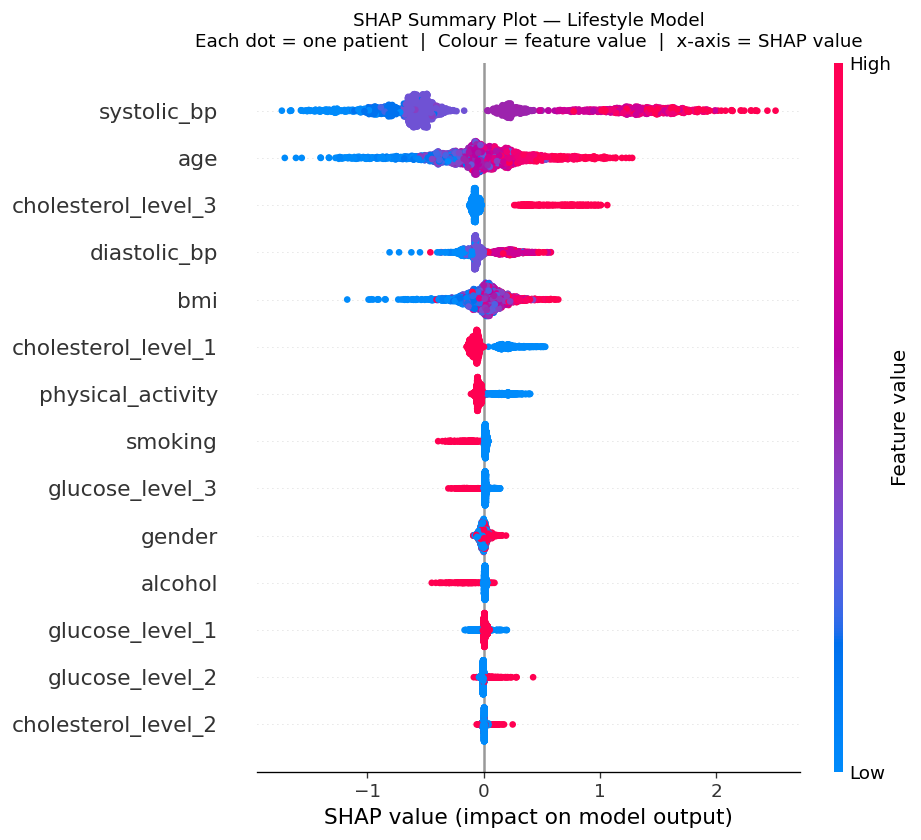

  ✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/shap_summary_lifestyle.png
  [Fig 2] SHAP bar plot — Clinical ...


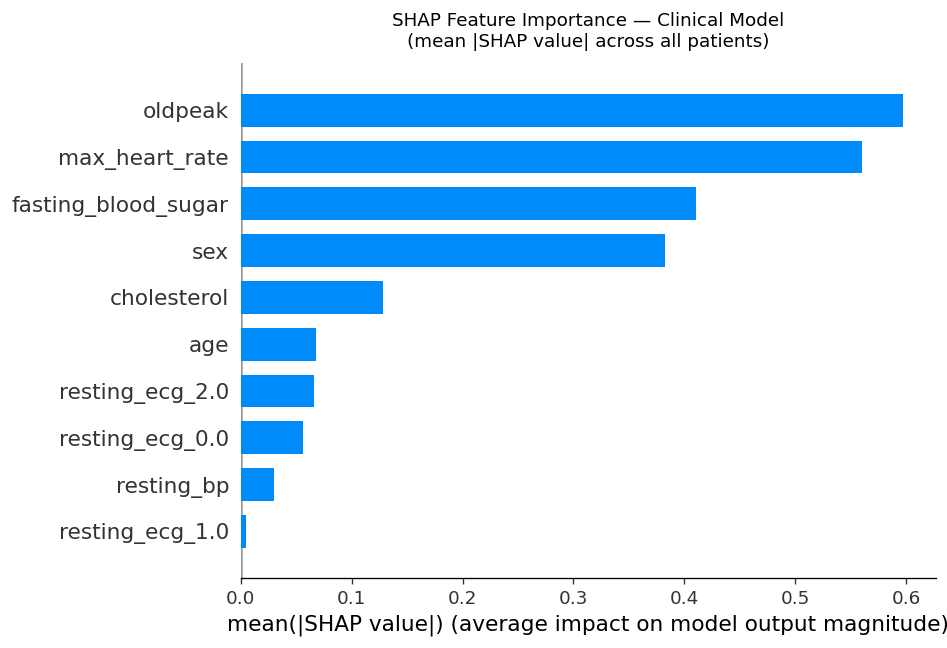

  ✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/shap_bar_clinical.png
  [Fig 3] Waterfall plots — Clinical (3 patients) ...


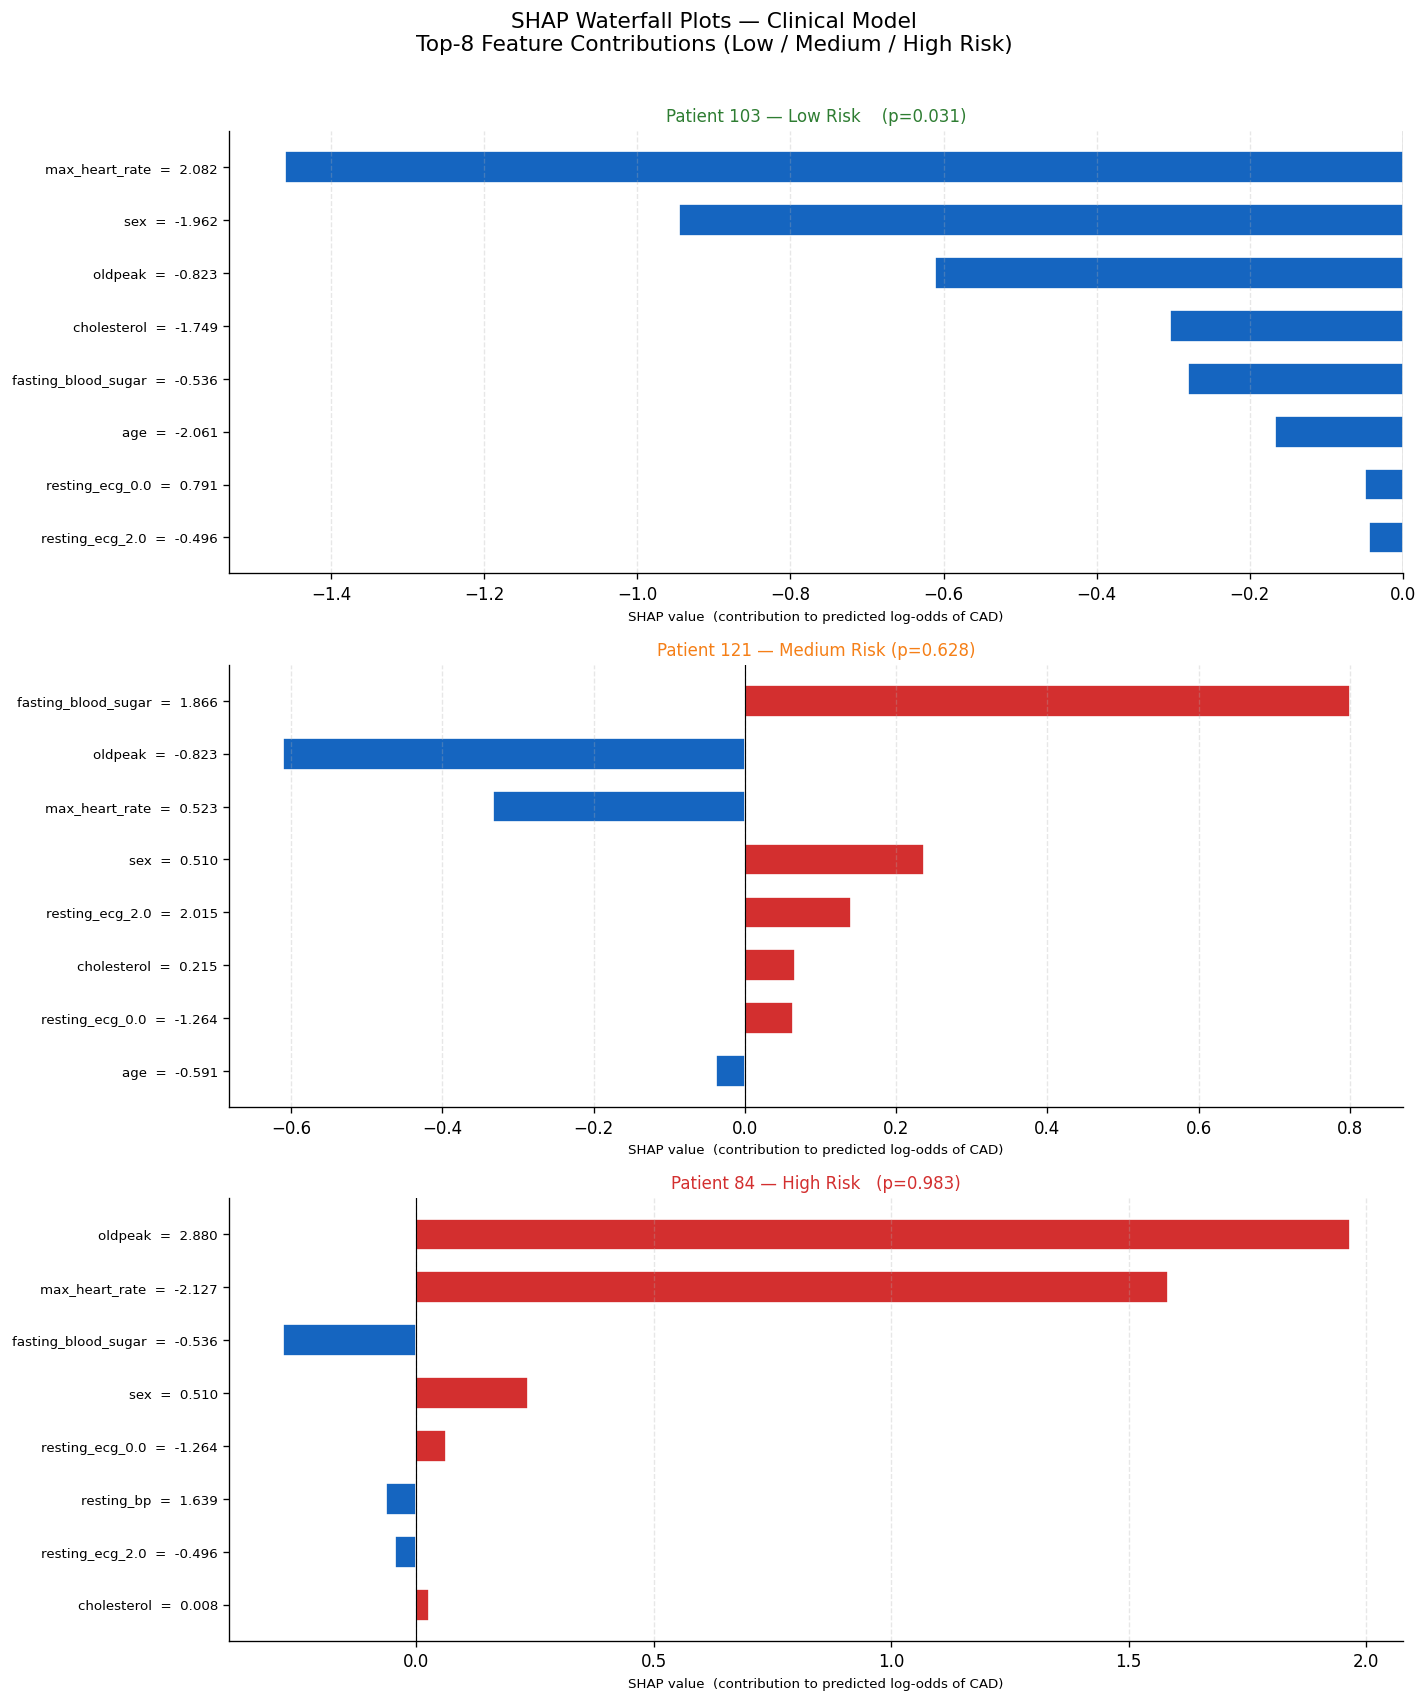

  ✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/shap_waterfall_clinical.png
  [Fig 4] Domain attribution stacked bar ...


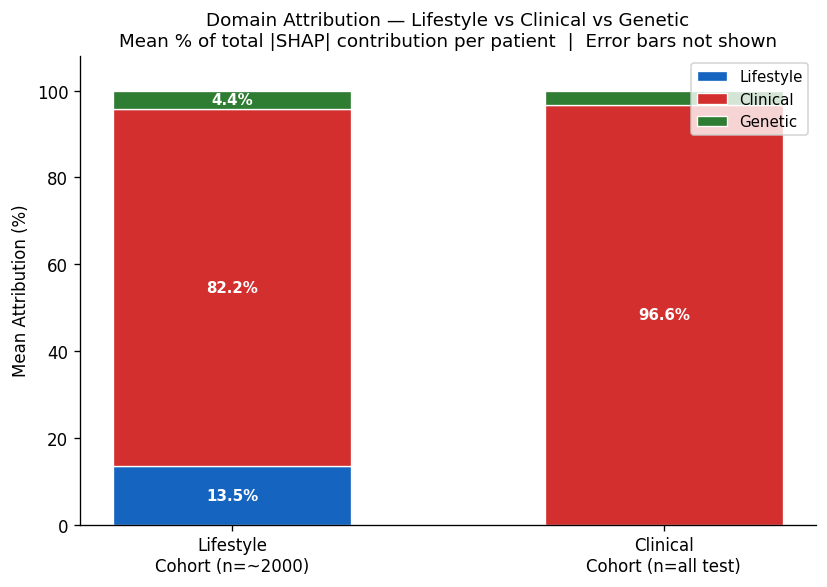

  ✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/domain_attribution.png

[SECTION 8 COMPLETE] ✅


In [9]:
print('='*60)
print('  SECTION 8: Visualisations')
print('='*60)

plt.rcParams.update({
    'figure.dpi'      : 120,
    'savefig.dpi'     : 300,
    'font.size'       : 10,
    'axes.titlesize'  : 12,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

DOMAIN_COLORS = {
    'lifestyle': '#1565C0',
    'clinical' : '#d32f2f',
    'genetic'  : '#2E7D32',
}

# ─────────────────────────────────────────────────────────────────────────────
# Figure 1: SHAP Summary Plot — Lifestyle
# ─────────────────────────────────────────────────────────────────────────────
print('  [Fig 1] SHAP summary plot — Lifestyle ...')
fig1 = plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_ls,
    X_shap_ls_scaled,
    feature_names=LS_FEATURES,
    show=False,
    max_display=14,
)
plt.title(
    'SHAP Summary Plot — Lifestyle Model\n'
    'Each dot = one patient  |  Colour = feature value  |  x-axis = SHAP value',
    fontsize=11, pad=10
)
plt.tight_layout()
fig1_path = os.path.join(FIG_DIR, 'shap_summary_lifestyle.png')
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'  ✅ Saved: {fig1_path}')

# ─────────────────────────────────────────────────────────────────────────────
# Figure 2: SHAP Bar Plot — Clinical
# ─────────────────────────────────────────────────────────────────────────────
print('  [Fig 2] SHAP bar plot — Clinical ...')
fig2 = plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values_cl,
    X_shap_cl_scaled,
    feature_names=CL_FEATURES,
    plot_type='bar',
    show=False,
    max_display=10,
)
plt.title(
    'SHAP Feature Importance — Clinical Model\n(mean |SHAP value| across all patients)',
    fontsize=11, pad=10
)
plt.tight_layout()
fig2_path = os.path.join(FIG_DIR, 'shap_bar_clinical.png')
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'  ✅ Saved: {fig2_path}')

# ─────────────────────────────────────────────────────────────────────────────
# Figure 3: Waterfall Plots — 3 Clinical Patients (Low / Medium / High Risk)
# ─────────────────────────────────────────────────────────────────────────────
print('  [Fig 3] Waterfall plots — Clinical (3 patients) ...')

# Use the full clinical test predictions to select representative patients
p_cl_test_all = clinical_pipeline.predict_proba(X_cl_test)[:, 1]

# Align SHAP index with test set (shap_values_cl was computed on full X_cl_test)
idx_low  = int(np.argmin(p_cl_test_all))
idx_med  = int(np.argsort(p_cl_test_all)[len(p_cl_test_all) // 2])
idx_high = int(np.argmax(p_cl_test_all))

fig3, axes3 = plt.subplots(3, 1, figsize=(12, 14))
fig3.suptitle(
    'SHAP Waterfall Plots — Clinical Model\nTop-8 Feature Contributions (Low / Medium / High Risk)',
    fontsize=13, y=1.01
)

for ax, idx, label, color in [
    (axes3[0], idx_low,  f'Low Risk    (p={p_cl_test_all[idx_low]:.3f})',  '#2E7D32'),
    (axes3[1], idx_med,  f'Medium Risk (p={p_cl_test_all[idx_med]:.3f})',  '#F57F17'),
    (axes3[2], idx_high, f'High Risk   (p={p_cl_test_all[idx_high]:.3f})', '#d32f2f'),
]:
    sv          = shap_values_cl[idx]
    feats       = X_shap_cl_scaled.iloc[idx]
    sorted_idx  = np.argsort(np.abs(sv))[::-1][:8]
    top_names   = [CL_FEATURES[j] for j in sorted_idx]
    top_sv      = sv[sorted_idx]
    top_vals    = feats.values[sorted_idx]

    bar_colors  = ['#d32f2f' if v > 0 else '#1565C0' for v in top_sv]
    ax.barh(range(len(top_sv)), top_sv, color=bar_colors, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(
        [f'{n}  =  {v:.3f}' for n, v in zip(top_names, top_vals)],
        fontsize=8
    )
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_title(f'Patient {idx} — {label}', fontsize=10, color=color, pad=6)
    ax.set_xlabel('SHAP value  (contribution to predicted log-odds of CAD)', fontsize=8)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(SHAP_FIG_OUT, dpi=300, bbox_inches='tight')
plt.show()
print(f'  ✅ Saved: {SHAP_FIG_OUT}')

# ─────────────────────────────────────────────────────────────────────────────
# Figure 4: Domain Attribution Stacked Bar — Both Cohorts
# ─────────────────────────────────────────────────────────────────────────────
print('  [Fig 4] Domain attribution stacked bar ...')

DOMAIN_COLS_PLOT = [d for d in ['lifestyle', 'clinical', 'genetic']
                    if d in attr_ls.columns and d in attr_cl.columns]

ls_means = attr_ls[DOMAIN_COLS_PLOT].mean()
cl_means = attr_cl[DOMAIN_COLS_PLOT].mean()

fig4, ax4 = plt.subplots(figsize=(7, 5))
x      = np.arange(2)
bottom = np.zeros(2)

for domain in DOMAIN_COLS_PLOT:
    vals = np.array([ls_means.get(domain, 0), cl_means.get(domain, 0)])
    bars = ax4.bar(
        x, vals, bottom=bottom,
        label=domain.capitalize(),
        color=DOMAIN_COLORS.get(domain, '#888888'),
        width=0.55, edgecolor='white', linewidth=0.8
    )
    for bar, v in zip(bars, vals):
        if v > 4:
            ax4.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{v:.1f}%',
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold'
            )
    bottom += vals

ax4.set_xticks(x)
ax4.set_xticklabels(['Lifestyle\nCohort (n=~2000)', 'Clinical\nCohort (n=all test)'],
                    fontsize=10)
ax4.set_ylabel('Mean Attribution (%)', fontsize=10)
ax4.set_title(
    'Domain Attribution — Lifestyle vs Clinical vs Genetic\n'
    'Mean % of total |SHAP| contribution per patient  |  Error bars not shown',
    fontsize=11
)
ax4.legend(loc='upper right', fontsize=9, framealpha=0.8)
ax4.set_ylim(0, 108)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
plt.tight_layout()

domain_fig_path = os.path.join(FIG_DIR, 'domain_attribution.png')
plt.savefig(domain_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'  ✅ Saved: {domain_fig_path}')

print('\n[SECTION 8 COMPLETE] ✅')


---
# Section 9 — Final Summary

## Key findings

### Independent pipeline architecture
No cross-cohort fusion was performed. Each dataset (Lifestyle ~13,700; Clinical ~238)
was processed as a fully independent pipeline, respecting the fundamental mismatch
in sample populations, feature spaces, and data collection protocols.

### Calibration
Per-cohort Platt scaling (sigmoid, cv=5) was applied to the NB7 integrated
probabilities. This corrects any residual miscalibration introduced by the
PRS blending step, ensuring predicted probabilities are interpretable as
event rates (a prerequisite for clinical deployment).

### SHAP explainability
SHAP values were computed for each cohort's actual champion model — `TreeExplainer` or `LinearExplainer`, auto-selected by model type, not assumed (see Section 6 edit log; the clinical model is Logistic Regression, not XGBoost, as of NB6's 2026-07-25 fix). Both provide:
- Theoretically grounded per-feature, per-patient attributions
- Direction of effect (positive = increases predicted CAD risk)
- Magnitude comparable across features and patients

**Scope limitation (restated from header):** none of this SHAP analysis attributes anything to genetics. PRS enters through NB7's fixed arithmetic blend, not as a trained feature, so the "genetic" domain below is a constant offset applied equally to every patient — not a per-patient SHAP computation.

### Domain attribution
Three-domain attribution (Lifestyle / Clinical / Genetic) quantifies the relative
contribution of modifiable and non-modifiable risk factors at the individual level.
This directly supports **precision prevention** — tailoring interventions to the
dominant risk domain for each patient.

## Outputs produced
| File | Description |
|------|-------------|
| `Outputs/Explainability/shap_values_lifestyle.pkl` | SHAP bundle (lifestyle) |
| `Outputs/Explainability/shap_values_clinical.pkl`  | SHAP bundle (clinical) |
| `Outputs/Explainability/domain_attributions.csv`   | Per-patient domain % |
| `Outputs/Integrated/nb8_evaluation_summary.csv`    | AUC/Brier comparison table |
| `Outputs/Figures/shap_summary_lifestyle.png`       | SHAP dot summary (lifestyle) |
| `Outputs/Figures/shap_bar_clinical.png`            | SHAP bar importance (clinical) |
| `Outputs/Figures/shap_waterfall_clinical.png`      | 3-patient waterfall (clinical) |
| `Outputs/Figures/domain_attribution.png`           | Stacked attribution bar chart |


In [10]:
print('='*60)
print('  ✅ NOTEBOOK 8 COMPLETE — Calibration & Explainability')
print('='*60)

print('\n  Evaluation summary (Base vs Integrated vs Calibrated):')
print(eval_df.to_string(index=False))

print('\n  Domain attribution (mean %):')
for label, df in [('Lifestyle cohort', attr_ls), ('Clinical cohort', attr_cl)]:
    print(f'\n  {label}:')
    for d in DOMAIN_COLS_PLOT:
        if d in df.columns:
            print(f'    {d:<12}: {df[d].mean():.1f}%')

print('\n  All outputs saved to CAD_DT_Final/Outputs/')
print('  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')


  ✅ NOTEBOOK 8 COMPLETE — Calibration & Explainability

  Evaluation summary (Base vs Integrated vs Calibrated):
   Cohort                  Model  Test_AUC  Test_Brier
Lifestyle       Lifestyle — Base    0.8024      0.1796
Lifestyle Lifestyle — Integrated    0.8024      0.1814
Lifestyle Lifestyle — Calibrated    0.8022      0.1800
 Clinical        Clinical — Base    0.8935      0.1338
 Clinical  Clinical — Integrated    0.8935      0.1394
 Clinical  Clinical — Calibrated    0.8896      0.1455

  Domain attribution (mean %):

  Lifestyle cohort:
    lifestyle   : 13.5%
    clinical    : 82.2%
    genetic     : 4.4%

  Clinical cohort:
    lifestyle   : 0.0%
    clinical    : 96.6%
    genetic     : 3.4%

  All outputs saved to CAD_DT_Final/Outputs/
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
